In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

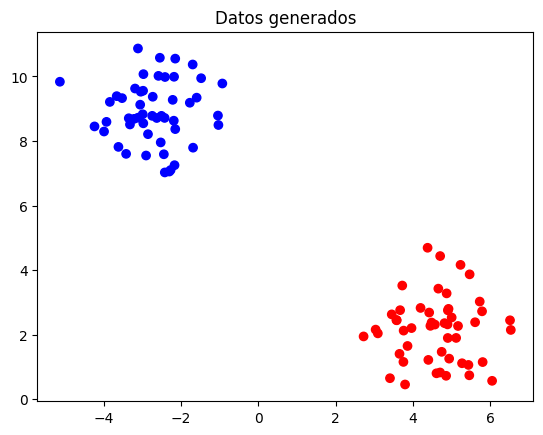

In [ ]:
X, y = make_blobs(n_samples=100, centers=2, random_state=42)

y = np.where(y == 0, -1, 1)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
plt.title("Datos generados")
plt.show()

In [ ]:
class Perceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.errors = []

    def activation(self, x):
        return np.where(x >= 0, 1, -1)

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation(linear_output)

    def train(self, X, y):
        n_features = X.shape[1]
        self.weights = np.random.randn(n_features)
        self.bias = np.random.randn()

        self.errors = []

        for epoch in range(self.epochs):
            error_count = 0

            for xi, target in zip(X, y):
                output = self.predict(xi)
                update = self.lr * (target - output)

                if update != 0:
                    error_count += 1

                self.weights += update * xi
                self.bias += update

            self.errors.append(error_count)

        return self

In [ ]:
def plot_decision_boundary(X, y, model, title):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')

    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

    x_vals = np.linspace(x_min, x_max, 100)

    # Recta: w1*x + w2*y + b = 0 → y = -(w1*x + b)/w2
    y_vals = -(model.weights[0] * x_vals + model.bias) / model.weights[1]

    plt.plot(x_vals, y_vals)
    plt.title(title)
    plt.show()

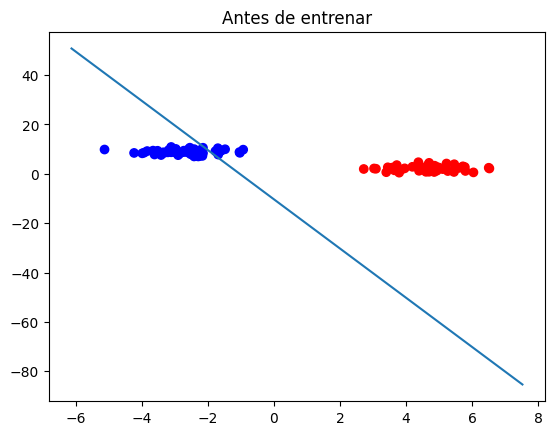

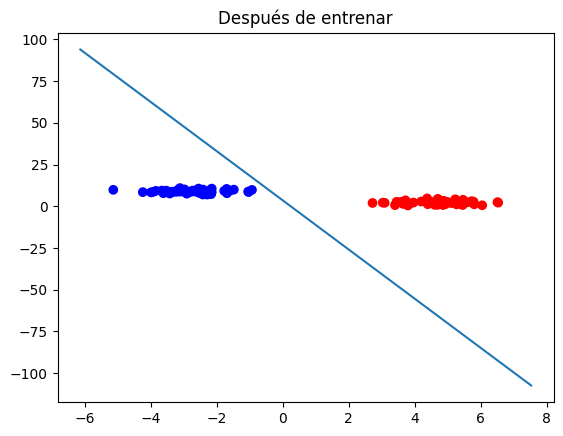

In [ ]:
model = Perceptron(lr=0.01, epochs=50)

# Antes de entrenar
model.weights = np.random.randn(2)
model.bias = np.random.randn()
plot_decision_boundary(X, y, model, "Antes de entrenar")

# Entrenar
model.train(X, y)

# Después de entrenar
plot_decision_boundary(X, y, model, "Después de entrenar")

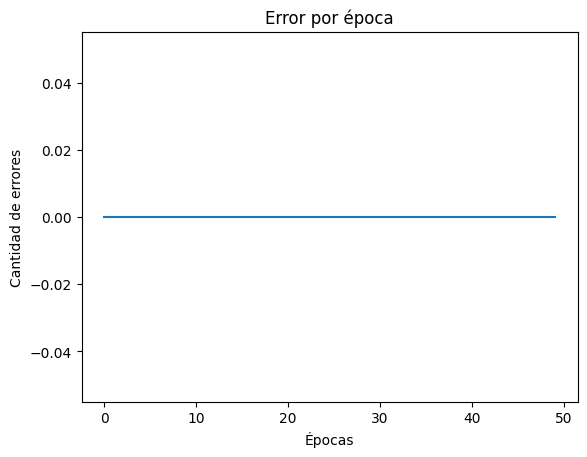

In [ ]:
plt.plot(model.errors)
plt.title("Error por época")
plt.xlabel("Épocas")
plt.ylabel("Cantidad de errores")
plt.show()

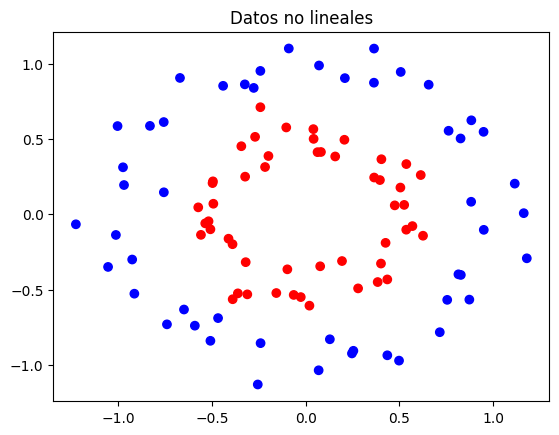

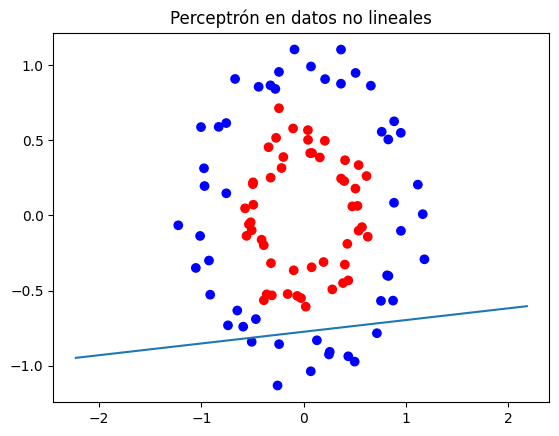

In [ ]:
from sklearn.datasets import make_circles

X2, y2 = make_circles(n_samples=100, noise=0.1, factor=0.5)
y2 = np.where(y2 == 0, -1, 1)

plt.scatter(X2[:,0], X2[:,1], c=y2, cmap='bwr')
plt.title("Datos no lineales")
plt.show()

model2 = Perceptron(lr=0.01, epochs=50)
model2.train(X2, y2)

plot_decision_boundary(X2, y2, model2, "Perceptrón en datos no lineales")

## **EXPERIMENTAR**

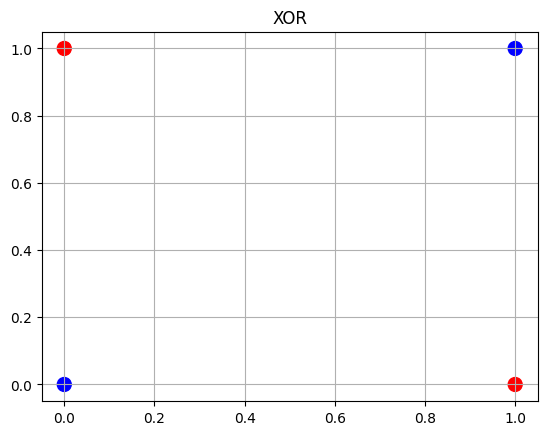

In [ ]:
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([-1, 1, 1, -1])

plt.scatter(X_xor[:,0], X_xor[:,1], c=y_xor, cmap='bwr', s=100)
plt.grid()
plt.title("XOR")
plt.show()

## ¿Por qué el perceptrón no puede resolver XOR? Dibujarlo y explicar.

No existe una línea recta que separe las clases.

El perceptrón solo aprende fronteras lineales.

XOR necesita una frontera no lineal → por eso falla.

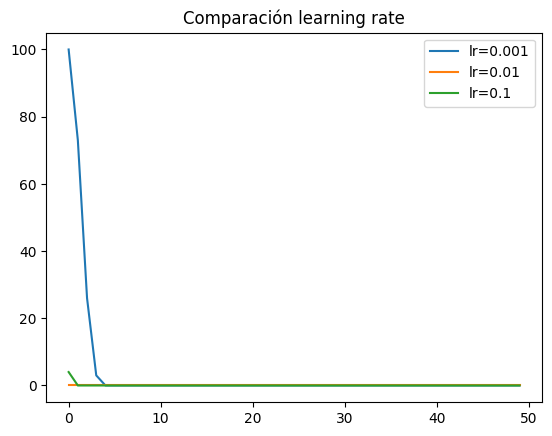

In [ ]:
for lr in [0.001, 0.01, 0.1]:
    model = Perceptron(lr=lr, epochs=50)
    model.train(X, y)
    plt.plot(model.errors, label=f"lr={lr}")

plt.legend()
plt.title("Comparación learning rate")
plt.show()

## ¿Qué pasa si cambián el learning rate? Probar 3 valores y comparar.

🔵 Muy chico → aprende lento

🟢 Intermedio → buen equilibrio

🔴 Muy grande → puede oscilar o no converger

## ¿Cuántas épocas necesita para converger? ¿De qué depende?

No existe un número fijo de épocas para que el perceptrón converja. Esto depende de varios factores:

- **Separabilidad de los datos**:
  - Si los datos son linealmente separables, el perceptrón converge en una cantidad finita de épocas (llega a una solución sin errores).
  - Si los datos no son separables, el perceptrón no converge completamente y siempre habrá errores.

- **Learning rate (tasa de aprendizaje)**:
  - Un valor muy pequeño hace que el aprendizaje sea más lento (requiere más épocas).
  - Un valor muy grande puede hacer que el modelo no se estabilice.

- **Inicialización de los pesos**:
  - Dependiendo de los valores iniciales, puede tardar más o menos en converger.

- **Ruido en los datos**:
  - Si hay datos mal clasificados o con ruido, la convergencia puede ser más lenta o no alcanzarse.
